# Lesson 1 — Token economics and cost forecasting

**Module 1 · ~8 minutes · API key optional** (only the last cell spends money)

This is the notebook you take back to a budget review. We will count tokens on the same instruction written five ways, price one million identical calls across a live rate card, then watch three toggles — agent steps, cache hits, and routing — move the monthly number more than any vendor discount will.

> **Presenting:** token cost is a writing decision *before* it is a model decision.

### What you will be able to do

1. Explain why two prompts with the same meaning can differ several times in tokens — and therefore in dollars.
2. Compute the spread between the cheapest and most expensive model for **identical behaviour** (~107× on this rate card).
3. Forecast a workload **per completed task**, with the three multipliers that dominate: agent steps, long-context tier, retry rate.


### How to work through this notebook

Run cells **top to bottom**. Each section tells you what is about to happen *before* you run the code.

| Marker | What it means |
|---|---|
| **About to happen** | What the next cell will do |
| **Watch for** | The number or field that makes the point — pause on it |
| **Why it matters** | The Monday-morning decision this should change |
| **Presenting:** | Live-demo cue. Students: treat this as the takeaway |

A **cost ledger** prints at the end of every notebook that spends money.


In [1]:
import sys
from pathlib import Path

HERE = Path.cwd()
for candidate in (HERE, HERE / "notebooks"):
    if (candidate / "coursekit.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise FileNotFoundError(
        "coursekit.py not found. Open Jupyter from the course repo root "
        "or from the notebooks/ folder."
    )

import matplotlib.pyplot as plt
import pandas as pd

from coursekit import (
    boot, complete, cost, usd, ntok, token_pieces, forecast, ledger,
    log_call, cache_breakeven, PRICES, MODELS, show,
)

cfg = boot()
print(f"\nLive provider: {cfg.provider}")
print("Need the other vendor? Set LLM_PROVIDER=openai or LLM_PROVIDER=anthropic in .env and re-run this cell.")


  Provider : none (offline)
  Arithmetic cells still run. Live cells will use rehearsal fallbacks.
  Add OPENAI_API_KEY or ANTHROPIC_API_KEY to .env for live calls.
  Rate card: verified 5 Sep 2026 — re-check before presenting.

Live provider: offline
Need the other vendor? Set LLM_PROVIDER=openai or LLM_PROVIDER=anthropic in .env and re-run this cell.


The cell above loads `.env`, chooses **OpenAI or Anthropic** from the key you have, and prints the three model tiers this notebook will call.

**Watch for:** a banner with `Provider`, `floor`, `mid`, `frontier`.
- If it names a vendor, live cells will spend a few cents.
- If it says `offline`, arithmetic still runs. Live cells print a rehearsal fallback instead of crashing — useful on a plane, not a substitute for a real key on caching / routing / eval lessons.

Switch vendor by setting `LLM_PROVIDER=openai` or `LLM_PROVIDER=anthropic` in `.env` and re-running that cell.


---
## 1. Tokenizer roulette — you pay for the shape, not the meaning

**About to happen.** We encode one instruction — *refund order 4471* — in five forms: terse, polite prose, JSON, a markdown table, and an "enterprise" version with Salesforce-style identifiers. Meaning does not change. Token count will.

**Watch for:** the spread (`max / min`) and `chars_per_token`. English prose sits near 4 characters per token. Identifiers and punctuation do not. JSON braces are billed at the same rate as the word `refund`.

**Why it matters.** Prompt style, serialization format, and field names are cost decisions. You can cut spend this afternoon with no new tooling and no approval.

> **Presenting:** after the table, ask the room for their worst offender — a custom field, an ID format, a boilerplate disclaimer — and paste it in the next cell.


In [2]:
variants = {
    "terse":        "Refund order 4471.",
    "polite prose": "Could you please go ahead and process a refund for the customer order "
                    "number 4471 at your earliest convenience? Thank you very much.",
    "JSON":         '{"action": "refund", "order_id": "4471", "reason": "customer_request"}',
    "markdown row": "| action | order_id | reason |\n| refund | 4471 | customer_request |",
    "enterprise":   "Please execute REFUND_TXN on SalesOrder__c record a0X5f000001ABCDEAA2 "
                    "per policy FIN-REF-07 (see KB article KB0043921).",
}

rows = [
    dict(form=k, tokens=ntok(v), chars=len(v), chars_per_token=round(len(v) / ntok(v), 2))
    for k, v in variants.items()
]
df = pd.DataFrame(rows).sort_values("tokens")
show(df)
print(f"\nSpread: {df.tokens.max() / df.tokens.min():.1f}x for the same instruction")
print("tiktoken o200k_base is an OpenAI encoding. Anthropic will count slightly differently.")
print("A $/1M comparison across vendors is incomplete without this.")


,form,tokens,chars,chars_per_token
0,terse,6,18,3.00
3,markdown row,18,67,3.72
2,JSON,21,70,3.33
1,polite prose,27,132,4.89
4,enterprise,38,119,3.13



Spread: 6.3x for the same instruction
tiktoken o200k_base is an OpenAI encoding. Anthropic will count slightly differently.
A $/1M comparison across vendors is incomplete without this.


### Try your own string

**About to happen.** We split one identifier into the tokens the model actually sees.

**Watch for:** a Salesforce-style id like `a0X5f000001ABCDEAA2` shattering into 6–10 pieces. Replace the string with something from your own systems.

**Why it matters.** The "~4 characters per token" rule of thumb is for English prose. Internal SKUs, UUIDs, and API names are a hidden tax on every call.


In [3]:
mine = "a0X5f000001ABCDEAA2"   # <-- replace with the room's worst offender
print(f"{mine!r} -> {ntok(mine)} tokens")
print("pieces:", token_pieces(mine))
print("One 'word' shattered. Structural syntax and identifiers bill at the same rate as meaning.")


'a0X5f000001ABCDEAA2' -> 10 tokens
pieces: ['a', '0', 'X', '5', 'f', '000', '001', 'ABCDE', 'AA', '2']
One 'word' shattered. Structural syntax and identifiers bill at the same rate as meaning.


---
## 2. The 107× slide, computed live

**About to happen.** One million identical assistant turns: 800 input tokens, 200 output tokens. We price that workload on every model in the rate card and plot the monthly bill. The *only* thing that changes is the model.

**Watch for:** cheapest vs dearest (`$168/mo` vs `$18,000/mo` on this card) and the `x_vs_cheapest` column. That ratio is ~107×.

**Why it matters.** Model tier is the largest single line on an inference bill. Teams that "just use the best model" are paying a two-order-of-magnitude premium for work a volume tier often handles.

Prices are illustrative, last checked **5 September 2026**. They move. If someone challenges a row, open the provider pricing page — that is the credibility move, not a footnote.

> **Presenting:** pause on the bar chart. Do not skip to the forecast until the room has felt the spread.


,model,monthly,x_vs_cheapest
0,deepseek-v4-flash,$168,1.000000
1,gpt-5.6-luna,$400,2.400000
2,gemini-3.5-flash-lite,$740,4.400000
3,gemini-3.8-flash,"$1,350",8.000000
4,claude-haiku-4-5,"$1,800",10.700000
5,claude-sonnet-5,"$3,600",21.400000
6,gpt-5.6-terra,"$4,000",23.800000
7,gpt-5.6-sol,"$7,200",42.900000
8,claude-opus-5,"$9,000",53.600000
9,gpt-6-astra,"$18,000",107.100000



SPREAD: 107x  ($168.00/mo -> $18,000.00/mo)


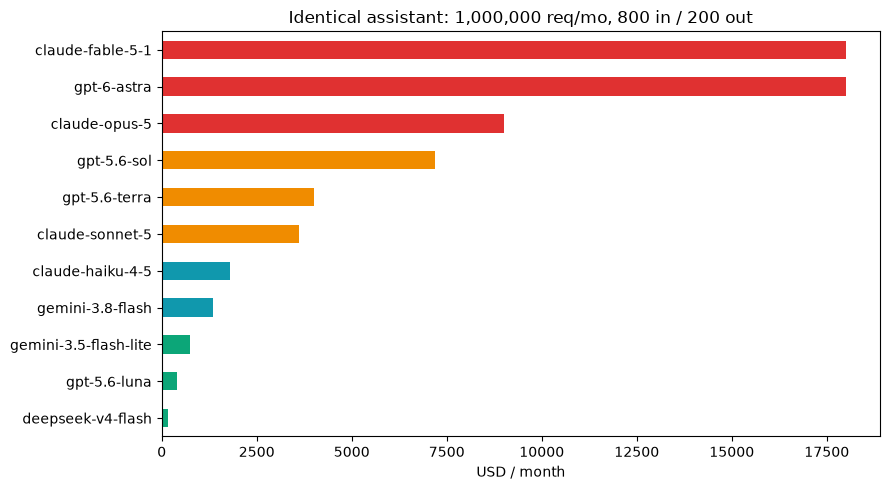

In [4]:
REQUESTS, T_IN, T_OUT = 1_000_000, 800, 200

rows = [dict(model=m, monthly=cost(m, T_IN * REQUESTS, T_OUT * REQUESTS)) for m in PRICES]
df = pd.DataFrame(rows).sort_values("monthly")
df["x_vs_cheapest"] = (df.monthly / df.monthly.min()).round(1)
show(df.style.format({"monthly": "${:,.0f}"}))

print(f"\nSPREAD: {df.x_vs_cheapest.max():.0f}x  "
      f"({usd(df.monthly.min())}/mo -> {usd(df.monthly.max())}/mo)")

ax = df.plot.barh(x="model", y="monthly", legend=False, figsize=(9, 5),
                  color=["#0CA678"] * 3 + ["#1098AD"] * 2 + ["#F08C00"] * 3 + ["#E03131"] * 3)
ax.set_xlabel("USD / month")
ax.set_ylabel("")
ax.set_title(f"Identical assistant: {REQUESTS:,} req/mo, {T_IN} in / {T_OUT} out")
plt.tight_layout()
plt.show()


---
## 3. The forecast function — with the three multipliers

List price per million tokens is not a forecast. A forecast is:

```
Monthly $ = Requests
          × [ fresh_in × P_in  +  cached_in × P_cache  +  out × P_out ] / 1e6
          × M_agent        ← steps / tool calls per user-visible task
          × M_context      ← long-context tier multiplier (1.0 flat, ~2.0 tiered)
          × (1 + R_retry)  ← retries, failed tool calls, regenerations
```

**About to happen.** Four scenarios on the same 1M-request workload. We only flip one assumption at a time so you can see which lever actually moves the bill.

**Watch for:** `cost per task` and `MONTHLY`. When `agent_steps` goes from 1 to 5, input is not 5× — it is triangular (`1+2+3+4+5 = 15×` the base input) because each step re-reads accumulated context. That is why **agent bills are input bills**.

**Why it matters.** The chat-assistant number your CFO approved is not the number you will run six months later. The difference is architecture, not adoption.

> **Presenting:** ask the room for *their* monthly volume and average prompt size, and type those into scenario A. The class becomes about their bill.


### Scenario A — the chat assistant your CFO was shown

One turn, mid-tier model, no cache, no retries. This is the number that got the project approved.


In [5]:
forecast(MODELS.mid, 1_000_000, 800, 200);


  model            claude-sonnet-5
  input tokens     800  (800 fresh / 0 cached)
  output tokens    200
  cost per task    $0.003600
  MONTHLY          $3,600.00


### Scenario B — the same feature, six months later, now agentic

Nothing about the user-visible product changed. It now calls tools for five steps and retries 8% of the time. Watch the monthly figure jump by an order of magnitude.


In [6]:
forecast(MODELS.mid, 1_000_000, 800, 200, agent_steps=5, retry_rate=0.08);


  model            claude-sonnet-5
  input tokens     12,000  (12,000 fresh / 0 cached)
  output tokens    1,000
  cost per task    $0.0367
  MONTHLY          $36,720.00


### Scenario C — same agent, prompt caching on

One hour of engineering: 80% of input is served from cache. Output is **never** cached, so this is a large partial fix, not a cure. Compare C to B, then wait for D.


In [7]:
forecast(MODELS.mid, 1_000_000, 800, 200,
         agent_steps=5, retry_rate=0.08, cache_hit_rate=0.80);


  model            claude-sonnet-5
  input tokens     12,000  (2,400 fresh / 9,600 cached)
  output tokens    1,000
  cost per task    $0.0181
  MONTHLY          $18,057.60


### Scenario D — route the routine 70% to the volume tier

70% of turns go to the floor model, 20% stay on mid, 10% escalate to frontier. This is the Coinbase move: better defaults, not tighter caps.


In [8]:
mix = {MODELS.floor: 0.70, MODELS.mid: 0.20, MODELS.frontier: 0.10}
blended = sum(
    share * forecast(m, 1_000_000, 800, 200, agent_steps=5,
                     retry_rate=0.08, cache_hit_rate=0.80, verbose=False)[0]
    for m, share in mix.items()
)
print(f"Blended monthly across a 70/20/10 tier mix: {usd(blended)}")
print("This is the Coinbase move: better defaults, not tighter caps.")


Blended monthly across a 70/20/10 tier mix: $14,446.08
This is the Coinbase move: better defaults, not tighter caps.


---
## 4. Best / base / worst — never hand finance a point estimate

**About to happen.** Three honest scenarios on the same volume: a tight/cached/routed best case, an expected base, and a no-cache long-context worst case.

**Watch for:** the best→worst spread (often ~50×). A single point estimate will be wrong.

**Why it matters.** Agentic cost is a distribution. Finance needs a range and the assumptions that produce each end — not a number that will be "proven wrong" by the first invoice.

> **Presenting:** "This range, not the middle number, is what you take to a budget review."


In [9]:
scenarios = {
    "best  (cached, routed, tight)": dict(model=MODELS.floor, agent_steps=3,
                                          cache_hit_rate=0.85, retry_rate=0.03),
    "base  (expected)":              dict(model=MODELS.mid, agent_steps=5,
                                          cache_hit_rate=0.60, retry_rate=0.08),
    "worst (no cache, long ctx)":    dict(model=MODELS.mid, agent_steps=9,
                                          cache_hit_rate=0.0, retry_rate=0.20,
                                          context_multiplier=2.0),
}
out = []
for name, kw in scenarios.items():
    m = kw.pop("model")
    monthly, per_task = forecast(m, 1_000_000, 800, 200, verbose=False, **kw)
    out.append(dict(scenario=name, model=m, cost_per_task=per_task, monthly=monthly))
df = pd.DataFrame(out)
show(df.style.format({"cost_per_task": "${:,.4f}", "monthly": "${:,.0f}"}))
print(f"\nSpread best->worst: {df.monthly.max() / df.monthly.min():.1f}x")
print("This range, not the middle number, is what you take to a budget review.")


,scenario,model,cost_per_task,monthly
0,"best (cached, routed, tight)",claude-haiku-4-5,$0.0043,"$4,252"
1,base (expected),claude-sonnet-5,$0.0227,"$22,723"
2,"worst (no cache, long ctx)",claude-sonnet-5,$0.2160,"$216,000"



Spread best->worst: 50.8x
This range, not the middle number, is what you take to a budget review.


---
## 5. Optional — a live round trip

**About to happen.** One real API call asking why output tokens cost more than input. We print the model's answer *and* the usage object you are actually billed against.

**Watch for:** `fresh_input` vs your tiktoken estimate. They will be close but not identical — each vendor tokenizes with its own encoding. Always trust the usage object.

**Why it matters.** Forecasts that ignore the billed usage object drift. This cell is the habit: every number we use later comes from the provider, not from our tokenizer.

Skip if you are offline; everything above already made the argument.


In [10]:
r = complete(
    "In two sentences: why are output tokens priced higher than input tokens?",
    model=MODELS.mid,
    max_tokens=120,
    label="live round trip",
)
print(r.text, "\n")
print("fresh_input =", r.fresh_input, "  output =", r.output_tokens,
      "  cache_read =", r.cache_read)
print("Always trust the usage object over tiktoken. Encodings differ by vendor.")
ledger()


⚠ No API key — using a rehearsal result.
live round trip                               $0.000828   in=14      out=80     cw=0       cr=0       offline fallback
[rehearsal fallback — live API call failed; continuing the teaching arc] 

fresh_input = 14   output = 80   cache_read = 0
Always trust the usage object over tiktoken. Encodings differ by vendor.

TOTAL SPENT IN THIS NOTEBOOK: $0.000828


,label,model,input,output,cache_write,cache_read,usd,note
0,live round trip,claude-sonnet-5,14,80,0,0,0.000828,offline fallback


---
## Takeaways

| Lever | What to remember |
|---|---|
| Shape of the prompt | Same meaning, different tokens. Rewrite before you optimise. |
| The 107× spread | Model tier is the largest single line on the bill. |
| `agent_steps` | Moves the forecast more than any price negotiation. Agent cost is input cost. |
| `cache_hit_rate` | Large partial fix, never a cure — output is never cached. |
| best / base / worst | The only honest way to forecast an agentic workload. |

**Try on Monday:** take one production prompt, count tokens three ways (terse / current / with your IDs), and price it at floor vs mid vs frontier for your real monthly volume.
